# Pauli Operators and Qiskit `Pauli` Class

Pauli operators form the foundation of quantum computing. They are single-qubit operators that generalize to multi-qubit systems via tensor products.
___

### 1. Single-Qubit Pauli Operators

The Pauli matrices are:


$$    
I =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}, \quad
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}, \quad
Y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}, \quad
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$


These operators are Hermitian, unitary, and form a basis for all single-qubit operators.

### 2. Multi-Qubit Pauli Operators

An n-qubit Pauli operator is:

$$
P = (-i)^q \cdot P_{n-1} \otimes \cdots \otimes P_0
$$

where:
- $P_i \in \{I, X, Y, Z\}$
- $q \in \mathbb{Z}_4 = \{0,1,2,3\}$

Example:

$$
-iXYZ = (-i)^1 \cdot X \otimes Y \otimes Z
$$

***Note:*** Qubit 0 corresponds to the **rightmost** character.

### 3. Key Properties of Pauli Operators


$$
X^2 = Y^2 = Z^2 = I
$$


$$
\text{Eigenvalues of Pauli operators} = \pm 1
$$


$$
P^\dagger = P, \quad P^2 = I
$$


Pauli operators form a group under multiplication (up to phase).



Pauli operators either **commute** or **anticommute**.

$$
[X, Y] = 2iZ, \quad [Y, Z] = 2iX, \quad [Z, X] = 2iY
$$

$$
\{X, Y\} = 0, \quad \{Y, Z\} = 0, \quad \{Z, X\} = 0
$$


$$
XY = iZ,\quad YX = -iZ
$$

$$
YZ = iX,\quad ZY = -iX
$$

$$
ZX = iY,\quad XZ = -iY
$$


Two Pauli strings:
- **Commute** if they differ on an even number of positions (ignoring I)
- **Anticommute** if they differ on an odd number of positions

Example:
- $X \otimes Z$ and $Z \otimes X$ commute
- $X$ and $Z$ anticommute

___

### Pauli operators in Qiskit

Qiskit represents a Pauli operator using:

- Binary vector $z \in \mathbb{Z}_2^n$
- Binary vector $x \in \mathbb{Z}_2^n$
- Phase $q \in \mathbb{Z}_4$


$$
P = (-i)^{q + z \cdot x} Z^z X^x
$$

Thus, operations are not matrix-based but rather as efficient **symplectic form** given above.

### Mapping

| z | x | Operator |
|--|--|--|
| 0 | 0 | I |
| 0 | 1 | X |
| 1 | 0 | Z |
| 1 | 1 | Y |

In [2]:
from qiskit.quantum_info import Pauli
import numpy as np

In [3]:
## Initialization of Pauli Objects
P = Pauli('XYZ')
print(P)

## Initialization of Pauli Objects with a phase 
P = Pauli('-iXYZ')
print(P)


print('P[0] =', repr(P[0]))
print('P[1] =', repr(P[1]))
print('P[2] =', repr(P[2]))
print('P[:] =', repr(P[:]))
print('P[::-1] =', repr(P[::-1]))

XYZ
-iXYZ
P[0] = Pauli('Z')
P[1] = Pauli('Y')
P[2] = Pauli('X')
P[:] = Pauli('XYZ')
P[::-1] = Pauli('ZYX')


#### Note:  Qubit-0 corresponds to the right-most Pauli character. For example 'XYZ' represents $ X \otimes Y \otimes Z$ with 'Z' on qubit-0, 'Y' on qubit-1, and 'X' on qubit-2.

In [4]:
z = np.array([1, 0, 1], dtype=bool) # 3 values implies it is for a 3 qubit Pauli operator, the first element is for the 0th qubit
x = np.array([0, 1, 1], dtype=bool)

P = Pauli((z, x, 2)) # phase q is 2
print(P)


# Acessing properties of the Pauli object
print("Number of qubits:", P.num_qubits)
print("Phase:", P.phase)
print("Z vector:", P.z)
print("X vector:", P.x)

print(str(P))        # will truncate the returned string for large numbers of qubits. The default truncation length is 50 characters.
print(P.to_label())  # no truncation done

-YXZ
Number of qubits: 3
Phase: 2
Z vector: [ True False  True]
X vector: [False  True  True]
-YXZ
-YXZ


In [ ]:
# Matrix representation of the Pauli operator

P = Pauli('XZ')

print(P.to_matrix()) # basically outputs the tensor product of the X and Z matrices

# useful methods for Pauli operators
P1 = Pauli('X')
P2 = Pauli('Z')
print(P1 ^ P2)  # tensor product 
print(P1.tensor(P2))
print(P1.expand(P2))
print(P1.compose(P2)) # the compose method is used to compute the product of two Pauli operators.
print(P1.dot(P2)) # right multiplication, whereas compose is left multiplication. So P1.compose(P2) = P1 * P2 and P1.dot(P2) = P2 * P1
print("Commutes:", P1.commutes(P2))
print("Anticommutes:", P1.anticommutes(P2))

print('Inserting Pauli operator at index 1:')
print(P.insert(1, Pauli('Y')))
print('Deleting Pauli operator at index 0:')
print(P.delete([0]))

# Convert Pauli operator to a quantum instruction to use as a gate in a quantum circuit
print(P.to_instruction())


[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]]
XZ
XZ
ZX
iY
-iY
Commutes: False
Anticommutes: True
Inserting Pauli operator at index 1:
XYZ
Deleting Pauli operator at index 0:
X
Instruction(name='pauli', num_qubits=2, num_clbits=0, params=['XZ'])


### Evolution under Clifford

- Schrödinger picture evolves the Pauli as $`P^\prime = C.P.C^\dagger`$

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.h(0)

P = Pauli('Z')
print(P.evolve(qc)) # outputs HZH = X

X


____

# Quantum Circuit

Circuits are at a low level of abstraction when building up quantum programs. They are the construct that is used to build up to higher levels of abstraction, such as the primitives of quantum computation, which accumulate data from many shots of quantum-circuit execution, along with advanced error-mitigation techniques and measurement optimizations, into well-typed classical data and error statistics.

In Qiskit, circuits can be defined in one of two regimes: an abstract circuit, which is defined in terms of virtual qubits and arbitrary high-level operations, like encapsulated algorithms and user-defined gates; a physical circuit (also called ISA circuit), which is defined in terms of the hardware qubits of one particular backend, and contains only operations that this backend natively supports. 

You convert from an abstract circuit to a physical circuit by using Qiskit’s transpilation package, of which the top-level access point is `transpile()`. If you define a circuit, where you intend the qubit indices to refer to physical qubits, you can use `QuantumCircuit.ensure_physical()` to rewrite the circuit’s metadata to ensure that Qiskit recognizes the circuit as a physical circuit, though unlike transpilation, this does not enforce that the basis-gates and hardware-coupling constraints will be respected.

In Qiskit, a quantum circuit is represented by the  `QuantumCircuit` class

#### Some Circuit concepts:


- abstract circuit

        A circuit (computational routine that defines a single execution to be taken on a QPU) defined in terms of abstract mathematical operations and virtual qubits. This is typically how you think about quantum algorithms; an abstract circuit can be made up of completely arbitrary unitary operations, measurements, and potentially real-time classical computation, with no restrictions about which qubits can interact with each other. 

        You turn an abstract circuit into a **physical circuit** (or ISA circuit) by using Qiskit’s transpilation package. Its definec interms of hardware qubits and only the quantum operations available in a particular QPU’s ISA.

- ancilla qubit

        An extra qubit that is used to help implement operations on other qubits, but whose final state is not important for the program.

- clbit

        A Qiskit-specific abbreviation meaning a single classical bit of data.

- gate

        A unitary operation on one or more qubits.

- hardware qubit

        The representation of a single qubit on a particular QPU. A hardware qubit has some physical quantum-mechanical system backing it, such as superconducting circuits; unlike a virtual qubit, it has particular coupling constraints and only certain gates can be applied to certain groups of hardware qubits.

        Qiskit does not distinguish logical qubits from any individual physical qubits when talking about hardware qubits. Both will have coupling constraints between them, only permit certain quantum operations on them, and have scheduling concerns between them. Qiskit abstracts these concerns together in the concept of hardware qubits.

- instruction set architecture (ISA)

        The abstract model of which operations are available on which sets of hardware qubits on one particular QPU.

- logical qubit

        A collection of several physical qubits that are controlled together by a QPU (from the user’s perspective) to apply real-time quantum error correction. A logical qubit is a type of hardware qubit for Qiskit.

- measurement

        The act of extracting one classical bit of a data from a single qubit state. This is an irreversible operation, and usually destroys entanglement and phase coherence between the target qubit and the rest of the system.

- physical qubit

        A controllable two-level quantum system. A QPU may expose this directly as its hardware qubit, or combine several physical qubits into a logical qubit.

- quantum processing unit (QPU)

        Hardware that runs quantum operations on quantum data. 

- real-time classical computation

        Any classical computation that can happen within the execution of a single shot of a circuit, where the results of the classical computation can affect later execution of the circuit. The amount of real-time classical computation available with particular QPUs will vary significantly dependent on many factors, such as the controlling electronics and the qubit technology in use. 

- unitary operation

        A reversible operation on a quantum state. All quantum gates are unitary operations.

- virtual qubit

        An abstract, mathematical qubit used to build an abstract circuit. Virtual qubits are how one typically thinks about quantum algorithms at a high level; we assume that all quantum gates are valid on all virtual qubits, and all virtual qubits are always connected to every other virtual qubit.

        When mapping to hardware, virtual qubits must be assigned to hardware qubits. Evaluating conditions to map a virtual circuit to a physical circuit is the job of Qiskit’s transpilation package.

### Quantum circuit attributes

In [17]:
from qiskit.circuit import QuantumCircuit, Parameter

# -------------------------
# Basic Circuit Properties
# -------------------------
qc = QuantumCircuit(2, 2, name="Example Circuit")
qc.measure([0], [1])

print("Circuit Instructions (qc.data):")
print(qc.data)
print()

print("Circuit Name:")
print(qc.name)
print()

print("Global Phase:")
print(qc.global_phase)
print()

print("Qubit Objects:")
print(qc.qubits)
print()

print("Number of Qubits:")
print(qc.num_qubits)
print()

print("Number of Classical Bits:")
print(qc.num_clbits)
print()


# -------------------------
# Metadata Example
# -------------------------
# Arbitrary user-defined dictionary of metadata for the circuit.

# Qiskit will not examine the content of this mapping, but it will pass it through the transpiler and reattach it to the output, so you can track your own metadata.

qc = QuantumCircuit(2, 2, metadata={'experiment_type': 'Bell state experiment'})

print("Circuit Metadata:")
print(qc.metadata)
print()


# -------------------------
# Parameterized Circuit
# -------------------------
a = Parameter("a")
b = Parameter("b")
elephant = Parameter("elephant")

circuit = QuantumCircuit(1)
circuit.rx(b, 0)
circuit.rz(elephant, 0)
circuit.ry(a, 0)

print("Circuit Parameters (sorted alphabetically):")
print(circuit.parameters)
print()

print("Number of Parameters:")
print(circuit.num_parameters)

print("Ancilla qubits:", circuit.ancillas)

Circuit Instructions (qc.data):
[CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=(<Clbit register=(2, "c"), index=1>,))]

Circuit Name:
Example Circuit

Global Phase:
0.0

Qubit Objects:
[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

Number of Qubits:
2

Number of Classical Bits:
2

Circuit Metadata:
{'experiment_type': 'Bell state experiment'}

Circuit Parameters (sorted alphabetically):
ParameterView([Parameter(a), Parameter(b), Parameter(elephant)])

Number of Parameters:
3
Ancilla qubits: []


- The `layout` attribute (typically populated after transpilation) shows how the virtual qubits in your circuit map to the physical qubits on a device.

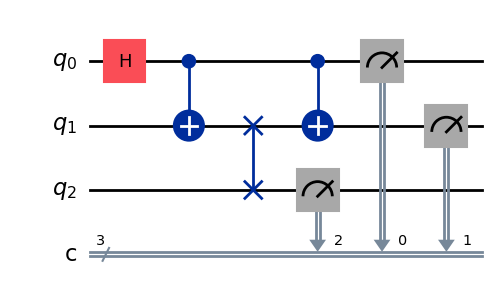

[0, 1, 2]


In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
 
# Create circuit to test transpiler on
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.swap(1, 2)
qc.cx(0, 1)
 
# Add measurements to the circuit
qc.measure([0, 1, 2], [0, 1, 2])

display(qc.draw('mpl'))
 
# Specify the QPU to target
backend = GenericBackendV2(3)
 
# Transpile the circuit
pass_manager = generate_preset_pass_manager(
optimization_level=1, backend=backend
)
transpiled = pass_manager.run(qc)
 
# Print the layout after transpilation
print(transpiled.layout.routing_permutation())



### Circuit Construction Methods

These methods help in creating and manipulating circuit objects.

In [119]:
qc2 = qc.copy_empty_like()
print("Empty copy of the circuit (same structure, no instructions):")
print(qc2)

qc_copy = qc.copy() # creates a deep copy of the circuit, including all instructions and properties
# Modify copy to show independence
qc_copy.x(0)
print("Copy of the circuit with a Pauli-X gate:")
print(qc_copy)

qasm_str = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
h q[0];
cx q[0],q[1];"""
qc = QuantumCircuit.from_qasm_str(qasm_str) #to import a circuit that is defined in OpenQASM 2.0 string format.
print("Circuit imported from OpenQASM string:")
print(qc)

from qiskit.circuit import Qubit
qc = QuantumCircuit(1)
new_bit = Qubit()
qc.add_bits([new_bit])
print("Circuit after adding a new qubit:")
print(qc)
qr = QuantumRegister(2, 'aux')
qc.add_register(qr)
print("Circuit after adding a new quantum register:")
print(qc)

#Add a real-time classical input variable. This is a feature for dynamic circuits where inputs might be provided at runtime.
from qiskit.circuit.classical import types
x_var = qc.add_input("x", types.Bool())
print("Successfully added input variable:", x_var)



Empty copy of the circuit (same structure, no instructions):
       
    q: 
       
    1: 
       
aux_0: 
       
aux_1: 
       
Copy of the circuit with a Pauli-X gate:
       ┌───┐
    q: ┤ X ├
       └───┘
    1: ─────
            
aux_0: ─────
            
aux_1: ─────
            
Circuit imported from OpenQASM string:
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Circuit after adding a new qubit:
   
q: 
   
1: 
   
Circuit after adding a new quantum register:
       
    q: 
       
    1: 
       
aux_0: 
       
aux_1: 
       
Successfully added input variable: Var(UUID('fc6f770e-8efc-40d2-938e-eaa5ff21f37f'), Bool(), name='x')


In [98]:
from qiskit.circuit import QuantumCircuit, Qubit
 
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure([0, 1, 2], [0, 1, 2])
 
# The `.qubits` and `.clbits` fields are not integers.
assert isinstance(qc.data[0].qubits[0], Qubit)
# ... but we can use `find_bit` to retrieve them.
#     this function can find the integer index of a qubit, which corresponds to its hardware index for a transpiled circuit.
assert qc.find_bit(qc.data[0].qubits[0]).index == 0
 
simple = [
    (
        instruction.operation.name,
        [qc.find_bit(bit).index for bit in instruction.qubits],
        [qc.find_bit(bit).index for bit in instruction.clbits],
    )
    for instruction in qc.data
]

print("Simplified circuit instructions:")
for instr in simple:
    print(instr)

Simplified circuit instructions:
('h', [0], [])
('cx', [0, 1], [])
('cx', [1, 2], [])
('measure', [0], [0])
('measure', [1], [1])
('measure', [2], [2])


- ##### `append`: The foundational method to add any Instruction object to the circuit. Most gate methods call this internally.
- ##### `compose`: Applies the instructions from one circuit onto specified qubits and/or clbits on another. By default, this creates a new circuit object, leaving original circuit untouched.  For most uses of this function, it is far more efficient to set ``inplace=True`` and modify the base circuit in-place.

##### Notice the difference
`append` → always modifies circuit. It adds a circuit as a single opaque instruction

`compose` → returns new circuit unless inplace=True. It flattens the circuit into individual gates

- ##### `delay`:Apply a delay (idle time) to a qubit. This is used in scheduling and noise characterization tasks. Delays represent idle/waiting time for qubits — they model scheduling pauses and exposure to decoherence, so they are useful when reasoning about timing and noise in experiments.

<class 'qiskit.circuit.instructionset.InstructionSet'>


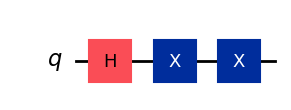

In [112]:
from qiskit.circuit.library import XGate
qc = QuantumCircuit(1)
qc.h(0)
# Append an X gate
qc.append(XGate(), [0]) # this modifies the original circuit in-place and returns an Instruction Set
print(type(qc.append(XGate(), [0]))) # <class 'qiskit.circuit.instructionset.InstructionSet'> 
qc.draw('mpl')


<class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>
     ┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ Y ├
     └───┘
     ┌───┐     
q_0: ┤ H ├─────
     ├───┤┌───┐
q_1: ┤ Y ├┤ X ├
     └───┘└───┘


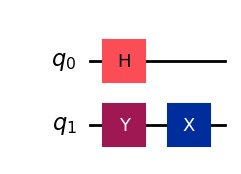

In [113]:
qc1 = QuantumCircuit(2)
qc1.h(0)
qc1.y(1)
qc2 = QuantumCircuit(1)
qc2.x(0)
# Compose qc2 onto qc1
print(type(qc1.compose(qc2, [1]))) # this creates a new circuit object (hence returns a quantum circuit) with the operations of qc2 applied on 1st qubit of qc1, but does not modify qc1 in-place. 
print(qc1) # qc1 is unchanged because compose does not modify in-place by default

#So if you want to use the modified circuit, you need to assign it back to qc or another variable.
qc = qc1.compose(qc2, [1])

# to modify qc1 in-place, you can set the inplace parameter to True
qc1.compose(qc2, [1], inplace= True)
print(qc1)

qc.draw('mpl')

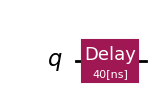

In [116]:
qc = QuantumCircuit(1)
qc.delay(40, 0, unit='ns')
qc.draw('mpl')

### Circuit Metrics & Scheduling

Circuit width
<bound method QuantumCircuit.width of <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x15b3f15a0>>
Circuit depth
9
Circuit operations
OrderedDict([('cx', 8), ('h', 5), ('x', 3), ('swap', 3)])
Duration: 6.266393999999999e-06
Demo qubit 0 duration: 2212
Demo qubit 0 start time: 26015
Demo qubit 0 stop time: 28227


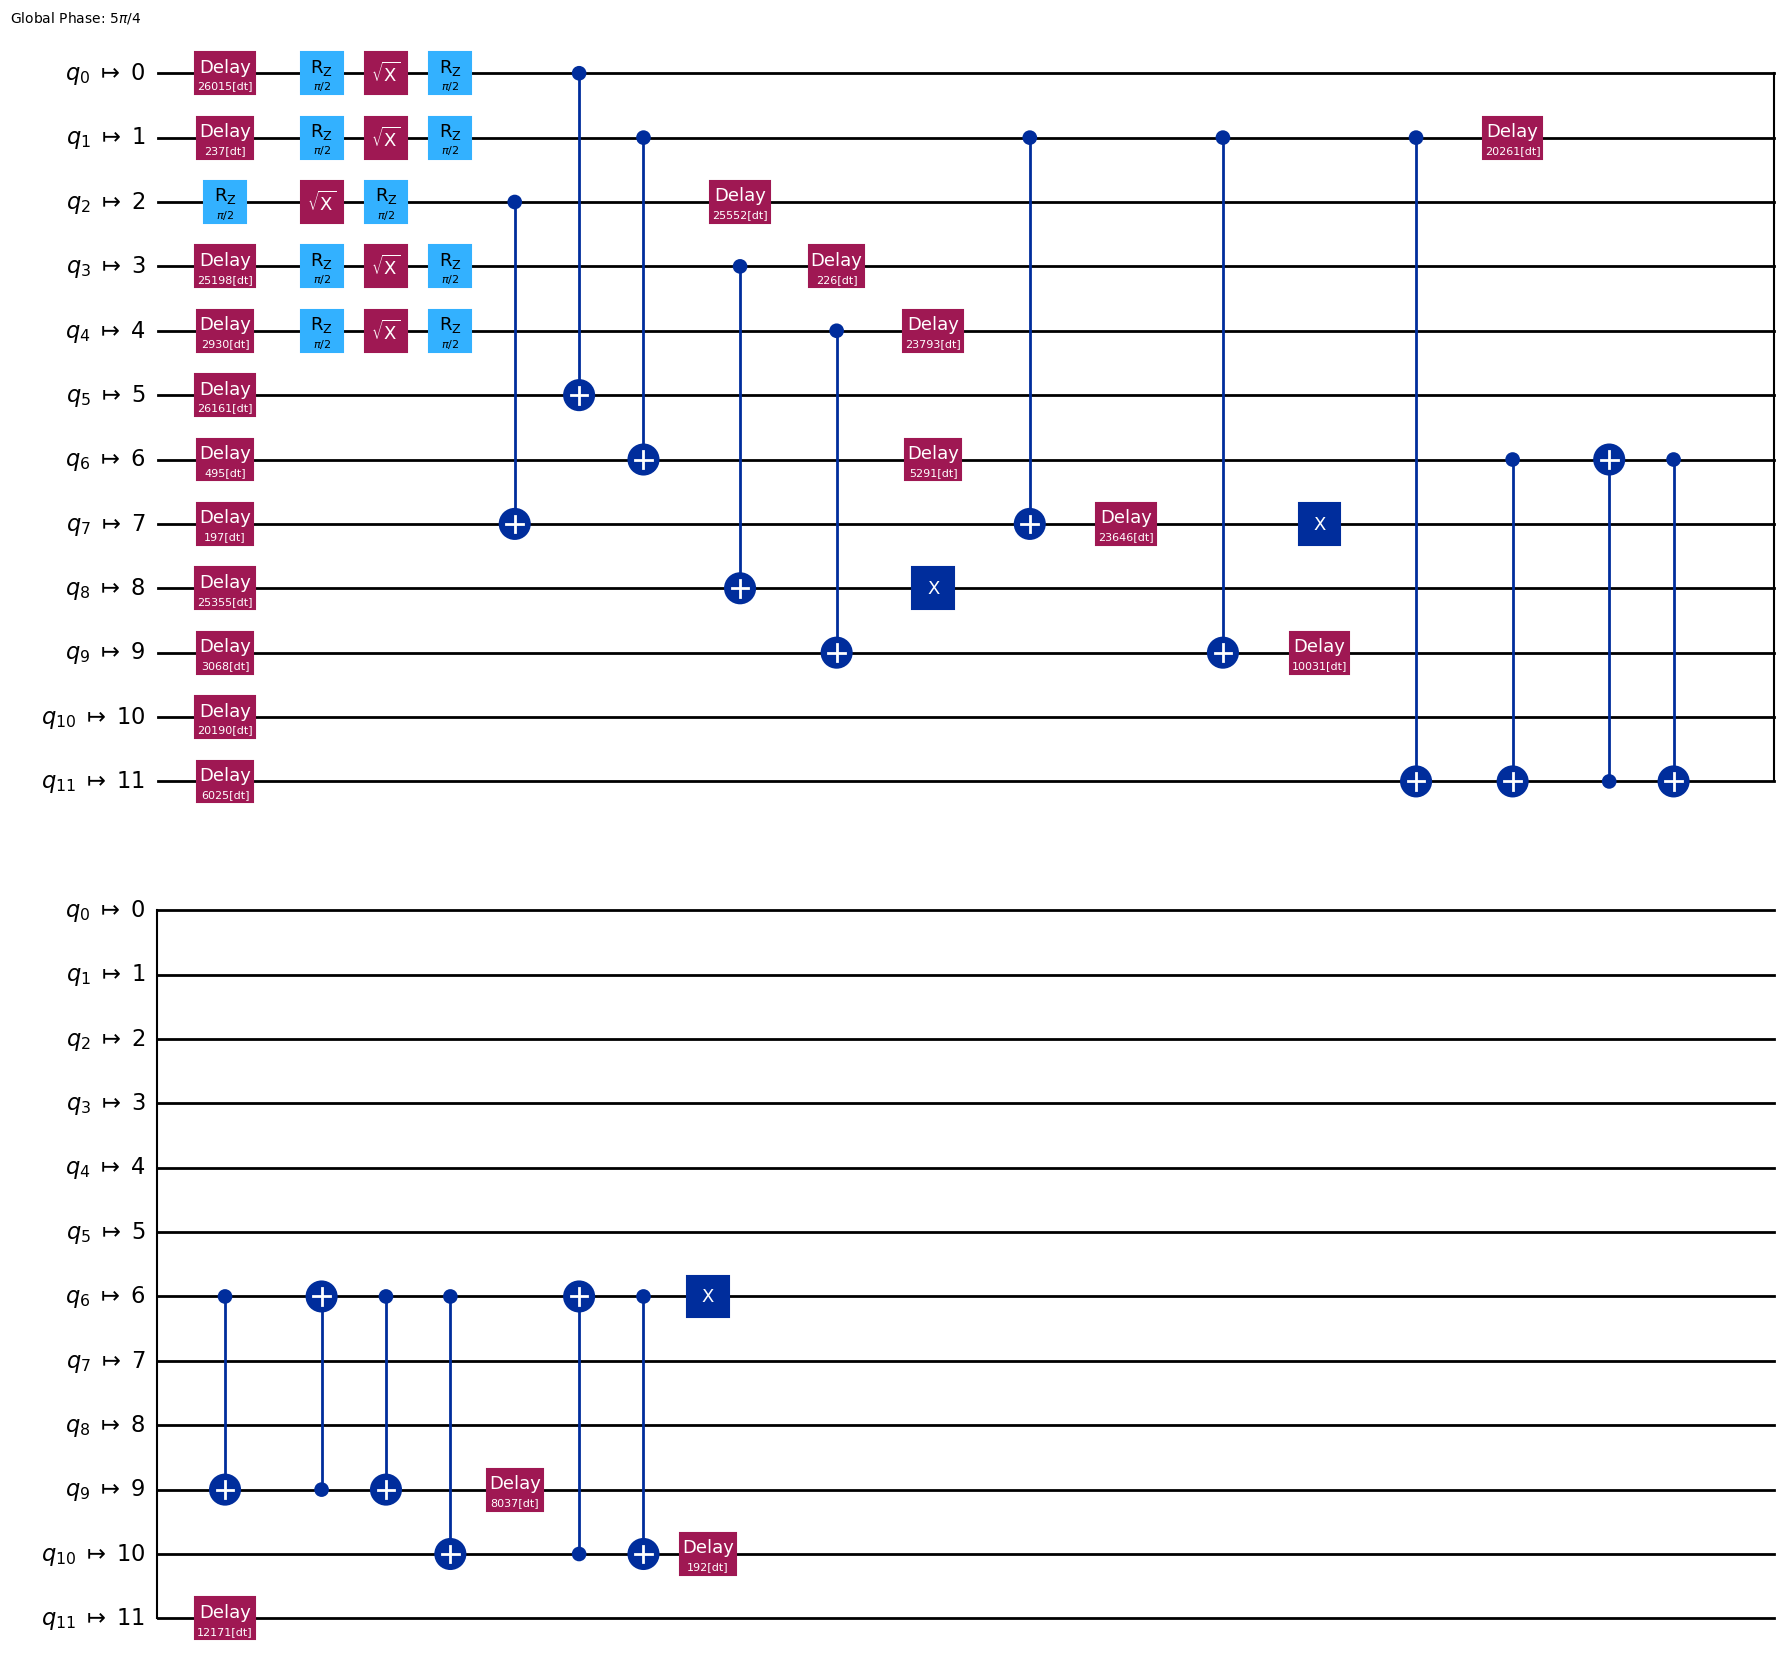

In [128]:
from qiskit import QuantumCircuit, transpile
qc = QuantumCircuit(12)
for idx in range(5):
   qc.h(idx)
   qc.cx(idx, idx+5)
 
qc.cx(1, 7)
qc.x(8)
qc.cx(1, 9)
qc.x(7)
qc.cx(1, 11)
qc.swap(6, 11)
qc.swap(6, 9)
qc.swap(6, 10)
qc.x(6)
# qc.delay(100, 0, unit='dt')

print("Circuit width")
print(qc.width)
print("Circuit depth")
print(qc.depth())
print("Circuit operations")
print(qc.count_ops())


from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager

# Use at least 2 qubits for the fake backend so multi-qubit basis gates exist;  Using a fake backend to simulate real hardware timing
backend = GenericBackendV2(num_qubits=12)
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
qc = pm.run(qc)
# Pass the backend target (timing info) to estimate_duration: Estimates the total duration of the circuit based on gate times provided by a backend
print(f"Duration: {qc.estimate_duration(backend.target)}")
# Transpile with scheduling (ALAP) to assign instruction start/stop times
qc_demo_scheduled = transpile(qc, backend=backend, optimization_level=1, scheduling_method='alap')
print("Demo qubit 0 duration:", qc_demo_scheduled.qubit_duration(0))
print("Demo qubit 0 start time:", qc_demo_scheduled.qubit_start_time(0))
print("Demo qubit 0 stop time:", qc_demo_scheduled.qubit_stop_time(0))
qc_demo_scheduled.draw('mpl')




Note: `qubit_start_time` and `qubit_stop_time`

These methods return the scheduled start and stop times for operations on a specific qubit.

Crucially, these methods will only return non-zero values if the circuit has been transpiled with a scheduling_method (such as 'alap' or 'asap'). The qc_scheduled object from the previous section was created without a scheduling pass, so its timing information remains at the default of zero, as shown below. This contrasts with the qc_demo_scheduled object, which was scheduled and therefore contains valid timing data.

Note that querying the qc_scheduled object will still yield zero for start and stop times, as the timing information is only present on the new object returned by transpile when a scheduling_method is specified.

# Circuit Operations



The `qiskit.circuit.library` is a collection of valuable circuits and building blocks for algorithms. Elements in the circuit library are either `QuantumCircuits` or `Instructions`, allowing them to be easily investigated or plugged into other circuits. 




## Matrix Representation of some Common Quantum Gates

### 1. Single-Qubit Gates

#### Pauli gates- already covered above

#### Hadamard Gate
$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

#### Phase Gate (S Gate)
$$
S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}
$$

#### T Gate
$$
T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}
$$



#### Rotation Gates

Rotation about X-axis:
$$
R_X(\theta) =
\begin{pmatrix}
\cos(\theta/2) & -i\sin(\theta/2) \\
-i\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}
$$

Rotation about Y-axis:
$$
R_Y(\theta) =
\begin{pmatrix}
\cos(\theta/2) & -\sin(\theta/2) \\
\sin(\theta/2) & \cos(\theta/2)
\end{pmatrix}
$$

Rotation about Z-axis:
$$
R_Z(\theta) =
\begin{pmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}
\end{pmatrix}
$$

---

### 2. Two-Qubit Gates

#### CNOT Gate
$$
\text{CNOT} =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}
$$

---

#### Controlled-Z Gate
$$
CZ =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix}
$$

---

#### SWAP Gate
$$
SWAP =
\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix}
$$

---

## Constructing Controlled Gates 
Instead of memorizing matrices, any controlled gate can be constructed using projectors.

If control is on one qubit, a controlled unitary $CU$ is:

$$
CU = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes U
$$

where, 

$$
|0\rangle\langle 0| =
\begin{pmatrix}
1 & 0 \\
0 & 0
\end{pmatrix}
\quad
|1\rangle\langle 1| =
\begin{pmatrix}
0 & 0 \\
0 & 1
\end{pmatrix}
$$

#### Examples: 
$$
\text{CNOT} = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes X
$$

$$
CZ = |0\rangle\langle 0| \otimes I + |1\rangle\langle 1| \otimes Z
$$


For two controls:

$$
CCU = (I - |11\rangle\langle 11|) \otimes I + |11\rangle\langle 11| \otimes U
$$



This can be generalized to any $n$ qubit control. For $n$ control qubits, define the projector onto the all-ones state:

$$
\Pi_{1^n} = |11\cdots1\rangle\langle 11\cdots1|
$$

Then the controlled unitary becomes:

$$
C^{(n)}U = (I - \Pi_{1^n}) \otimes I + \Pi_{1^n} \otimes U
$$


### More General Controls (Arbitrary Bitstring)

You can control on **any bitstring**, not just all 1s.

For a control string $b = b_1 b_2 \cdots b_n$, define:

$$
\Pi_b = |b\rangle\langle b|
$$

Then:

$$
CU = (I - \Pi_b)\otimes I + \Pi_b \otimes U
$$

#### Example: Control on Bitstring "2" (i.e., |10⟩)

Consider 2 control qubits and 1 target qubit. The value $2 = (10)_2$, so the control state is $|10\rangle$.

The projector is:
$$
\Pi_{10} = |10\rangle\langle 10| = (|1\rangle\langle 1|)\otimes(|0\rangle\langle 0|)
$$

The controlled operation is:
$$
C_{10}(U) = (I - \Pi_{10}) \otimes I + \Pi_{10} \otimes U
$$

For example for $U = X$, the matrix becomes, 

$$
C_{10}(X) =
\begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Only the subspace where control = $|10\rangle$ is affected. All other basis states remain unchanged.

___


### List of Standard gates on qiskit

<div style="display: flex; gap: 10px;">
  <img src="1Qgates.png" width="32%">
  <img src="2Qgates.png" width="32%">
  <img src="3Qgates.png" width="34%">
</div>

`GlobalPhaseGate(phase, label)`	: The global phase gate $e^{i\theta}$.  It does not take any qubit arguments.


In [ ]:
### Example usage

from qiskit.circuit.library import XGate, CCXGate
gate = XGate()

# getting the matrix representation of gates
print("X gate matrix:")
print(gate.to_matrix())             # X gate

print("√X gate matrix:")
print(gate.power(1/2).to_matrix())  # √X gate 
print("CX gate matrix:")
print(gate.control(1).to_matrix())  # CX (controlled X) gate
print("CCX gate matrix:")
print(CCXGate().to_matrix()) # CCX (Toffoli) gate



X gate matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
√X gate matrix:
[[0.5+0.5j 0.5-0.5j]
 [0.5-0.5j 0.5+0.5j]]
CX gate matrix:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]
CCX gate matrix:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


#### Note that gate is an instruction and can be appended to quantum circuit.

In [13]:
print(gate)

Instruction(name='x', num_qubits=1, num_clbits=0, params=[])


In [14]:
# To see the available standard gates and operations

from qiskit.circuit.library import get_standard_gate_name_mapping

gate_name_map = get_standard_gate_name_mapping()
print("These are the available standard gates and operations:", gate_name_map.keys())
print("********")
cx_object = gate_name_map["cx"]
print(cx_object)
print(type(cx_object))

These are the available standard gates and operations: dict_keys(['id', 'sx', 'x', 'cx', 'rz', 'r', 'c3sx', 'ccx', 'dcx', 'ch', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu3', 'cy', 'cz', 'ccz', 'global_phase', 'h', 'p', 'rccx', 'rcccx', 'rx', 'rxx', 'ry', 'ryy', 'rzz', 'rzx', 'xx_minus_yy', 'xx_plus_yy', 'ecr', 's', 'sdg', 'cs', 'csdg', 'swap', 'iswap', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'y', 'z', 'delay', 'reset', 'measure'])
********
Instruction(name='cx', num_qubits=2, num_clbits=0, params=[])
<class '_SingletonCXGate'>


### Instruction Modifiers

Methods that return a new version of the circuit with modified properties (e.g., controlled or inverted).

- `.control()` method is a powerful tool that takes an existing circuit or gate and returns a new version with one or more control qubits. This allows you to easily create controlled versions of complex operations without having to manually decompose them.
- `.inverse()` method computes the mathematical inverse (the conjugate transpose, or ) of a circuit. When applied, it returns a new circuit with all of the gates applied in the reverse order, and with each gate replaced by its own inverse.
- `.power()` method allows to raise a gate or circuit to a specific power. This is equivalent to applying the gate's unitary matrix  to itself $n$ times ().
-  `.reverse_ops()` method reverses the order of instructions in a circuit. It is important to note that this only reverses the order; it does not take the inverse of each gate (unlike the .inverse() method).



Main Circuit with Controlled H-Gate:


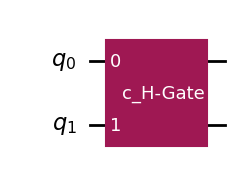


Inverted Circuit:


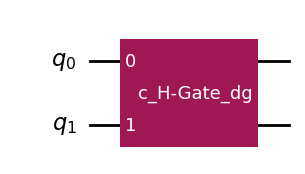

Power circuit (T^2):


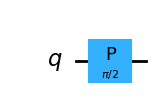


Reversed Circuit:


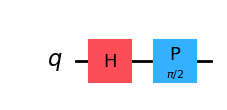

In [135]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import TGate

# Create a simple circuit for a single H-gate
qc_h = QuantumCircuit(1, name='H-Gate')
qc_h.h(0)

# Add one control qubit to the H-gate circuit
# The original qubit (0) becomes the target (now on wire 1)
# The new control is on wire 0
controlled_h_gate = qc_h.control(1)

# You can now use this new gate in another circuit
main_qc = QuantumCircuit(2)
main_qc.append(controlled_h_gate, [0, 1])
print("Main Circuit with Controlled H-Gate:")
display(main_qc.draw('mpl'))


# Now, compute the inverse
qc_inv = main_qc.inverse()

print("\nInverted Circuit:")
display(qc_inv.draw('mpl'))

# Create a circuit with a single T-gate
qc = QuantumCircuit(1)
qc.append(TGate().power(2), [0])

# The output diagram will show an S-gate (Phase Gate where theta=π/2), because T^2 = S
print("Power circuit (T^2):")
display(qc.draw('mpl'))

qc.h(0)
# Now, reverse the operations
qc_rev = qc.reverse_ops()
print("\nReversed Circuit:")
display(qc_rev.draw('mpl')) # first h and then T^2, reverse order compared to the original circuit



#### Apart from gate operations, there are also some non reversibel operations like `measure`, `reset`, `PauliProductMeasurement(pauli[, label])`. 

`measure` operation measures qubits on compuatational basis states and stores the result on classical registers. 

`reset` operation produces no classical data but instructs hardware to return the qubit to the $\ket{0}$ state. This is assumed to happen incoherently and to collapse any entanglement.

A Pauli Product Measurement corresponds to a joint projective measurement on multiple qubits, where the measured observable is a tensor product of Pauli operators. The outcome of this measurement is a single eigenvalue, either +1 or -1 indicating the eigenstate of the Pauli product. 

**Note:** Directives are operations to the quantum stack that are meant to be interpreted by the backend or the transpiler. In general, the transpiler or backend might optionally ignore them if there is no implementation for them. Example: `barrier`

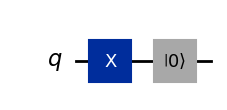

In [ ]:
# Reset a qubit to the |0> state mid-circuit. This is a non-unitary dynamic operation.

qc = QuantumCircuit(1)
qc.x(0)
qc.reset(0)
qc.draw('mpl')

#### General gates

Gates that are variadic, meaning that the number of qubits depends on the input.

In [23]:
from qiskit.circuit.library import DiagonalGate

diagonal = DiagonalGate([1, 1j])
print(diagonal.num_qubits)

diagonal = DiagonalGate([1, 1, 1, -1])
print(diagonal.num_qubits)

1
2


<div style="display: flex; gap: 10px;">
  <img src="Generalgates.png" width="35%">
  <img src="GeneralCircuits.png" width="35%">
</div>

#### Some examples 

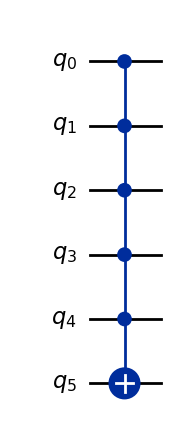

In [ ]:
# a multicontrol NOT gate 

from qiskit.circuit.library import MCXGate

qc = QuantumCircuit(6)
mcxgate = MCXGate(num_ctrl_qubits=5)
qc.compose(mcxgate).draw('mpl')  #compose operation applies the instructions from one circuit onto specified qubits and/or clbits on another. By default, this creates a new circuit object

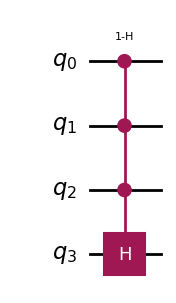

In [21]:
# a multicontrol multi-target gate
from qiskit.circuit.library import MCMTGate, HGate

mcmtGate = MCMTGate(gate=HGate(),num_ctrl_qubits=3,num_target_qubits=1) # the target qubit count must match the number of qubits the gate acts on, in this case HGate needs 1 qubit so num_target_qubits is set to 1
qc= QuantumCircuit(4,0)
qc.compose(mcmtGate).draw('mpl')

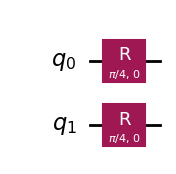

In [ ]:
# a global rotation around the X-axis by an angle theta for multiple qubits
from qiskit.circuit.library import GRX

qc= QuantumCircuit(2)
grx= GRX(num_qubits=2, theta=np.pi/4) # the GRX gate applies a rotation around the X-axis by an angle theta to each of the target qubits

## Arithmetic Circuits: Adders and Multipliers

Quantum arithmetic circuits implement classical operations (like addition and multiplication) **reversibly**, which is essential for quantum computation.

---

An adder computes:

$$
|a\rangle_n |b\rangle_n \;\longrightarrow\; |a\rangle_n |a + b\rangle
$$


- This often requires **ancilla qubits** (for carry bits)
- Can be implemented using:
  - Ripple-carry (gate-based, simple)
  - QFT-based (more parallel, fewer depth in theory)


For example, a full adder:
- Takes two registers + carry-in
- Outputs sum + carry-out

---


A multiplier computes:

$$
|a\rangle_n |b\rangle_n |0\rangle \;\longrightarrow\; |a\rangle_n |b\rangle_n |a \cdot b\rangle
$$

- Built using **controlled addition applied repeatedly**
- Requires larger ancilla space
- Typically implemented via:
  - Controlled additions
  - Shift-and-add logic
  - QFT-based methods

---

#### Qiskit functionalities

<div style="display: flex; gap: 10px;">
  <img src="Add.png" width="50%">
  <img src="Multiply.png" width="50%">
</div>

### Adder example

Example: 4+3=7.

- The below code adds A+B in place, that is B changes to A+B after the adder operation. 
- Adjust the size of register B and this the classical register "result" based on size of the expected output.

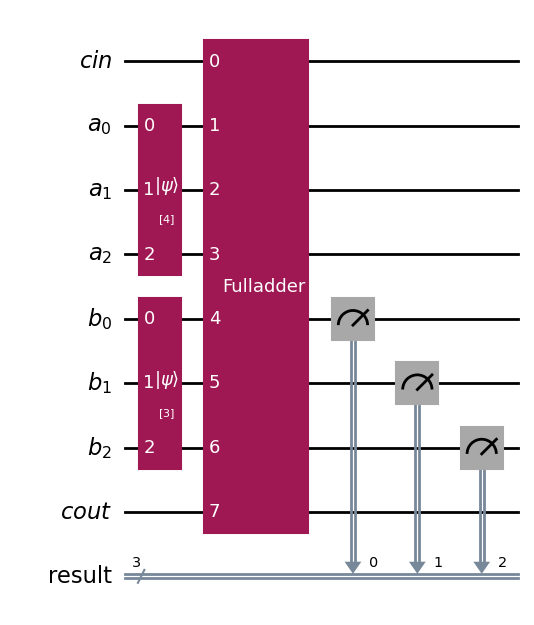

In [31]:
from qiskit.circuit.library import FullAdderGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

adder = FullAdderGate(3)  # Adder of 3-bit numbers

# Create the number A=2
reg_a = QuantumRegister(3, "a")
number_a = QuantumCircuit(reg_a)
number_a.initialize(4)  # Number 4; |100>

# Create the number B=3
reg_b = QuantumRegister(3, "b")
number_b = QuantumCircuit(reg_b)
number_b.initialize(3)  # Number 3; |011>

# Create a circuit to hold everything, including a classical register for
# the result
qregs = [
    QuantumRegister(1, "cin"),
    QuantumRegister(3, "a"),
    QuantumRegister(3, "b"),
    QuantumRegister(1, "cout"),
]
reg_result = ClassicalRegister(3, "result")
circuit = QuantumCircuit(*qregs, reg_result)

# Compose number initializers with the adder. Adder stores the result to
# register B, so we'll measure those qubits.
circuit = (
    circuit.compose(number_a, qubits=reg_a)
    .compose(number_b, qubits=reg_b)
    .compose(adder)
)
circuit.measure(reg_b, reg_result)
circuit.draw("mpl")

In [32]:
from qiskit.primitives import StatevectorSampler

result = StatevectorSampler().run([circuit]).result()

print(f"Count data:\n {result[0].data.result.get_int_counts()}") # expected output is 5 (101) with high probability, since 2+3=5

Count data:
 {7: 1024}


### Multiplier Example



Example: For a 2-bit multiplier code shown below:

- First 2 qubits → register \(a\)
- Next 2 qubits → register \(b\)
- Remaining qubits → output (product)

Total qubits = input + input + output

We are only interested in the **product register**, so we measure only those qubits.

Output qubits: [4, 5, 6, 7]


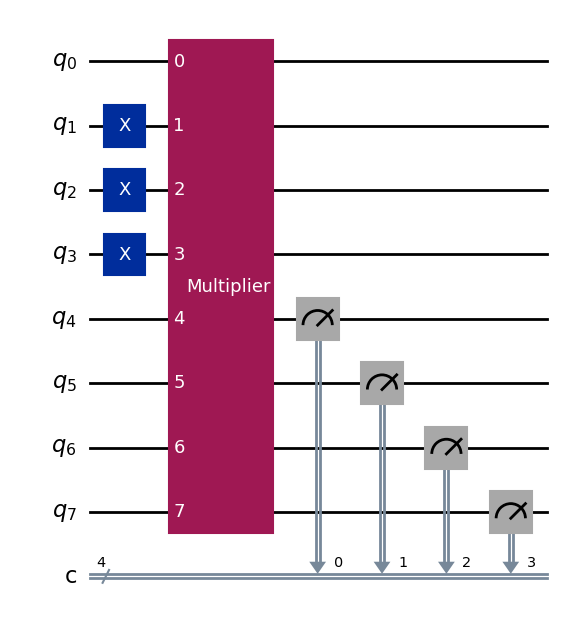

In [43]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import MultiplierGate

n = 2
mult = MultiplierGate(n)

num_qubits = mult.num_qubits

# Output register size = n (or sometimes 2n depending on implementation)
# In Qiskit MultiplierGate, output is last n qubits
output_qubits = list(range(2*n, num_qubits))

# Classical bits only for output
qc = QuantumCircuit(num_qubits, len(output_qubits))

# -------------------------
# Encode inputs
# a = 2 (10), b = 3 (11)
# -------------------------
qc.x(1)      # a = 10
qc.x(2)
qc.x(3)      # b = 11

# -------------------------
# Apply multiplier
# -------------------------
qc.append(mult, qc.qubits)

# -------------------------
# Measure ONLY output register
# -------------------------
qc.measure(output_qubits, range(len(output_qubits)))

print("Output qubits:", output_qubits)
qc.draw("mpl")

In [45]:
result = StatevectorSampler().run([qc]).result()

print(f"Count data:\n {result[0].data.c.get_int_counts()}") # expected output is 6 (110) with high probability, since 2*3=6

Count data:
 {6: 1024}


### Parametrized circuits

They are used as ansatz in a broad set of variational quantum algorithms.


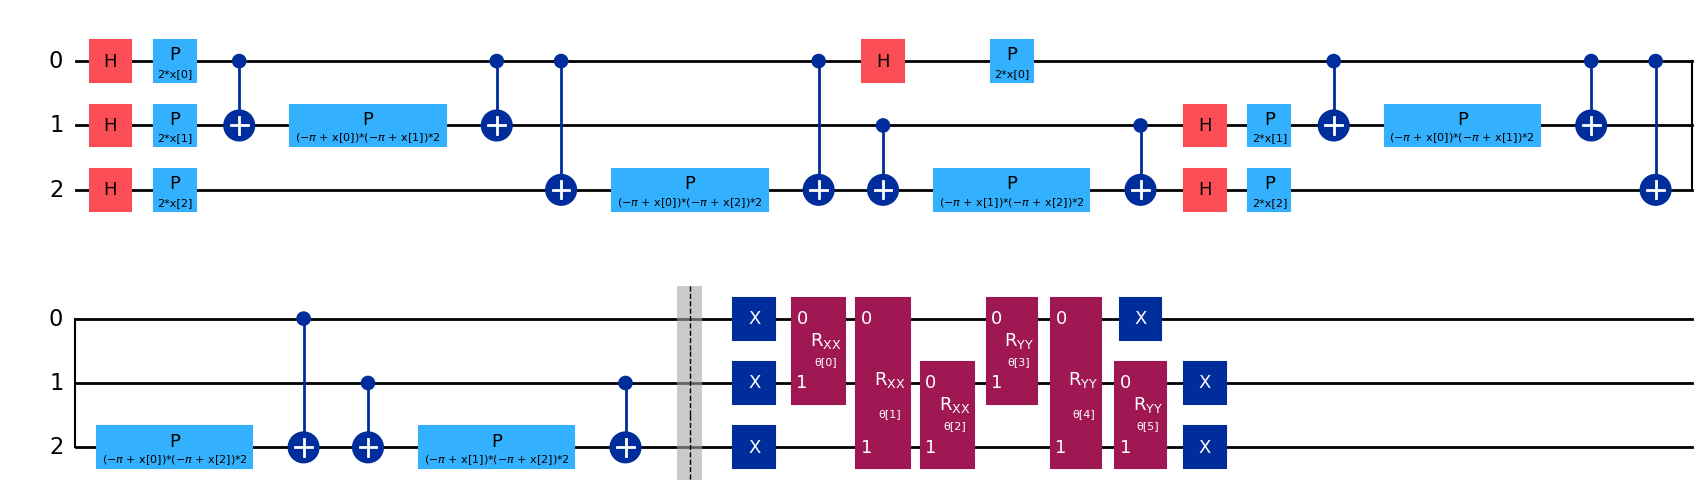

In [54]:
from qiskit.circuit.library import zz_feature_map, n_local

num_qubits = 3
ansatz= n_local(num_qubits, rotation_blocks='x', entanglement_blocks=["rxx", "ryy"], reps=1) # n_local is a simple ansatz that applies RX and RZ rotations to each qubit, followed by a layer of CNOTs. The reps parameter controls how many times this pattern is repeated.
circuit = zz_feature_map(num_qubits) # zz_feature_map is a feature map that encodes classical data into quantum states using ZZ interactions. It applies a series of RZ rotations followed by ZZ gates between pairs of qubits.
circuit.barrier()
circuit.compose(ansatz, inplace=True)

circuit.draw("mpl")

#### Other examples for ansatz and data encoding circuits supported in qiskit

<div style="display: flex; gap: 10px;">
  <img src="Ansatz.png" width="40%">
  <img src="data.png" width="55%">
</div>

## Data Preparation Circuits

Data preparation encodes classical data into a quantum state.

Given a normalized vector:
$$
\vec{x} = (x_0, x_1, \dots, x_{2^n-1})
$$

we prepare:
$$
|\psi\rangle = \sum_{i=0}^{2^n-1} x_i |i\rangle
$$

---

Expected state:
[0.5 0.5 0.5 0.5]

Obtained state:
[0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]


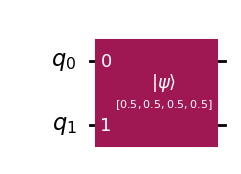

In [82]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
import numpy as np
from qiskit.quantum_info import Statevector

# Define a normalized statevector (2 qubits → 4 amplitudes)
state = np.array([1, 1, 1, 1]) / 2

qc = QuantumCircuit(2)

# Initialize a qubits in a specific state. 
#   Qubit initialization is done by first resetting the qubits to |0> followed by calling :class:`~qiskit.circuit.library.StatePreparation`
qc.initialize(state, [0, 1])

# Get final statevector directly
sv = Statevector.from_instruction(qc)

print("Expected state:")
print(state)

print("\nObtained state:")
print(sv.data)

qc.draw('mpl')

<class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


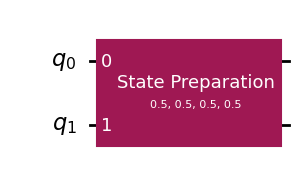

In [ ]:
# Arbitrary normalized state
state = np.array([0.5, 0.5, 0.5, 0.5])

qc = QuantumCircuit(2)

prep = StatePreparation(state)


# Notice the difference
# append() → always modifies circuit
# compose() → returns new circuit unless inplace=True

qc.append(prep, [0, 1]) # this modifies the original circuit in-place and returns an Instruction Set
# qc= qc.compose(prep, [0, 1]) # this creates a new circuit object (hence returns a quantum circuit) with the state preparation applied, but does not modify qc in-place. So if you want to use the modified circuit, you need to assign it back to qc or another variable.
# By default, compose() returns a new circuit, It does NOT change qc in-place. To modify the original circuit, you can set inplace=True in the compose method.

qc.draw('mpl')

#### Template circuits

Templates are functions that return circuits that compute the identity. They are used at circuit optimization where matching part of the template allows the compiler to replace the match with the inverse of the remainder from the template.

##### NCT (Not-CNOT-Toffoli) template circuits are Template circuits for XGate, CXGate, and CCXGate (Toffoli) gates

In [59]:
from qiskit.circuit.library.templates import template_nct_4b_1
from qiskit.quantum_info import Operator
import numpy as np

template = template_nct_4b_1()

identity = np.identity(2 ** len(template.qubits), dtype=complex)
data = Operator(template).data
np.allclose(data, identity)  # True, template_nct_4b_1 is the identity

True

### Other advanced circuit functionalities

<div style="display: flex; gap: 10px;">
  <img src="PauliRot.png" width="45%">
  <img src="AmpFunc.png" width="45%">
  
</div>

----

<div style="display: flex; gap: 10px;">
  <img src="Bool_logic.png" width="40%">
  <img src="QFTgate.png" width="50%">

</div>

----

<div style="display: flex; gap: 10px;">
  <img src="Oracle.png" width="40%">
  <img src="Adv_arith.png" width="40%">
  
</div>

### Some examples

#### 1. `AND` gate

Count data:
 {0: 1024}


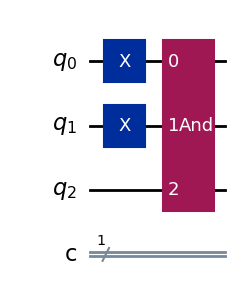

In [ ]:
# AND between 2 qubits, output stored in a third qubit

from qiskit.circuit.library import AndGate
from qiskit.primitives import StatevectorSampler

qc= QuantumCircuit(3, 1) # 3 qubits and 1 classical bit for measurement
qc.x(0) # set the first qubit to |1> and the second qubit to |0>, so the AND gate should output |1>
qc.x(1) # set the second qubit to |1>, so the AND gate should output |1>

andgate = AndGate(num_variable_qubits=2)

result = StatevectorSampler().run([qc]).result()

print(f"Count data:\n {result[0].data.c.get_int_counts()}")


qc.compose(andgate).draw('mpl')

#### 2. `LinearAmplitudeFunctionGate`

The `LinearAmplitudeFunctionGate` encodes a classical **linear function** into the **amplitudes of a quantum state**, rather than storing it as classical data.
$$
f(x) = \text{slope} \cdot x + \text{offset}
$$

This gate prepares the following state:

$$
\frac{1}{\sqrt{2^n}} \sum_{x} |x\rangle \left( \sqrt{1 - f(x)} \, |0\rangle + \sqrt{f(x)} \, |1\rangle \right)
$$

In the code below: 
- $x$: encoded in computational basis (state qubits)
- $f(x)$: encoded in **probability of measuring the objective qubit**
- `num_state_qubits` → represent input $x$
- `+1 objective qubit` → stores function value in amplitude
- Total qubits = `num_state_qubits + 1
- `slope`: coefficient of $x$
- `offset`: constant term
- `domain = [a, b]`: input range
- `image = [c, d]`: output range (must map $f(x)$ into [0,1] for valid amplitudes)
- The function is **rescaled internally** so that:
  $$
  0 \leq f(x) \leq 1
  $$

This function is useful for Quantum Amplitude estimation based applications.


$$
\tilde{f}(x) = \frac{f(x) - c}{d - c}
$$

So that:
$$
\tilde{f}(x) \in [0,1]
$$


The quantum circuit encodes $\tilde{f}(x),\text{NOT}f(x)$. And measurement gives: $P(\text{objective qubit} = 1 \mid x) = \tilde{f}(x)$


To recover \( f(x) \) from measurement:

$$
f(x) = \tilde{f}(x) \cdot (d - c) + c
$$




{6: 1816, 7: 2530, 5: 683, 0: 2485, 1: 1838, 2: 648}


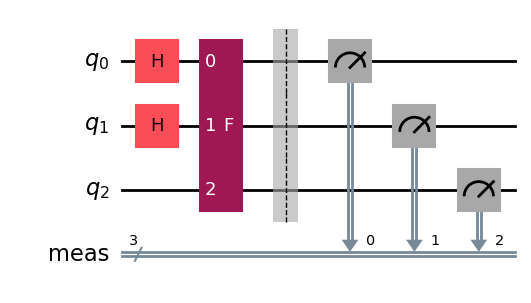

In [51]:
from qiskit.circuit.library import LinearAmplitudeFunctionGate

num_state_qubits = 2

laf = LinearAmplitudeFunctionGate(
    num_state_qubits=num_state_qubits,
    slope=1.0,
    offset=0.0,
    domain=[0, 3],   # 2 qubits → values 0 to 3
    image=[0, 3]
)

qc = QuantumCircuit(num_state_qubits + 1)

# create superposition over x
qc.h(range(num_state_qubits))

# apply function
qc.append(laf, qc.qubits)

qc.measure_all()

result = StatevectorSampler().run([qc], shots=10000).result()

counts= result[0].data.meas.get_int_counts()
# counts= result[0].data.meas.get_counts() # for birstring output
print(counts)


qc.compose(andgate).draw('mpl')

qc.draw("mpl")

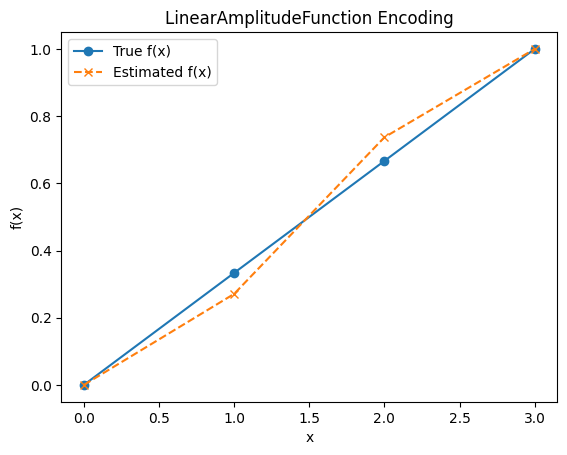

In [60]:

# --- process counts to estimate f(x) from the measurement results --- 

import matplotlib.pyplot as plt

data = {}

for bitstring, prob in counts.items():
    # reverse bitstring (Qiskit endian issue)
    b = format(bitstring, f'0{num_state_qubits+1}b')
    
    y_bit = b[0]
    x_bits = b[1:num_state_qubits+1]

    x = int(x_bits, 2)

    if x not in data:
        data[x] = {"0": 0, "1": 0}
    
    data[x][y_bit] += prob

# compute empirical f(x)
x_vals = []
f_est = []

for x in sorted(data.keys()):
    total = data[x]["0"] + data[x]["1"]
    prob_1 = data[x]["1"] / total if total > 0 else 0

    x_vals.append(x)
    f_est.append(prob_1)

# --- true function (after scaling!) ---
f_true = [x / 3 for x in x_vals]

# --- plot ---
plt.figure()
plt.plot(x_vals, f_true, marker='o', label="True f(x)")
plt.plot(x_vals, f_est, marker='x', linestyle='--', label="Estimated f(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("LinearAmplitudeFunction Encoding")
plt.legend()
plt.show()

#### `IntegerComparator`

The `IntegerComparator` compares a quantum register $|i\rangle$ with a classical integer $L$.

It flips a target qubit if:
- $i \geq L$ (default), or
- $i < L$ if `geq=False`




In [ ]:
from qiskit.circuit.library import IntegerComparator


def test_value(x):
    qc = QuantumCircuit(6, 1)  # decided by how many qubits the comparator needs 

    # encode x into first 3 qubits
    binary = format(x, '03b')
    for i, bit in enumerate(reversed(binary)):
        if bit == '1':
            qc.x(i)

    # comparator: check x < 6
    comp = IntegerComparator(3, 6, geq=False)
    qc.append(comp, qc.qubits)

    # measure flag qubit (last qubit)
    qc.measure(3, 0)

    result = StatevectorSampler().run([qc], shots=10000).result()

    counts= result[0].data.c.get_int_counts()

    return counts

# test values
for x in range(8):
    result = test_value(x)
    print(f"x = {x}, result = {result}")

x = 0, result = {1: 10000}
x = 1, result = {1: 10000}
x = 2, result = {1: 10000}
x = 3, result = {1: 10000}
x = 4, result = {1: 10000}
x = 5, result = {1: 10000}
x = 6, result = {0: 10000}
x = 7, result = {0: 10000}


## Custom Instructions & Gates in Qiskit (with Example)

In Qiskit, all operations are based on the Instruction class.
A Gate class is a special type of instruction that represents a **unitary operation**.

There are two ways to create custom behavior:

### Simple approach (recommended for quick use)

```python
from qiskit import QuantumCircuit

sub_qc = QuantumCircuit(2)
sub_qc.h(0)
sub_qc.cx(0, 1)

custom_gate = sub_qc.to_gate()

qc = QuantumCircuit(2)
qc.append(custom_gate, [0, 1])
qc.draw("mpl")
```

This is fast, but not ideal for reusable or parameterized designs.

---

### Advanced Approach: Subclassing `Gate`

When you need reusable, parameterized, or optimized gates, subclass `Gate`.


#### Example: Custom RXZ Gate 

⚠️ This only works when `theta` is **numerical** (not symbolic).







In [2]:
import numpy as np
import math
from qiskit.circuit import Gate, QuantumCircuit, Parameter

class RXZGate(Gate):
    """A custom two-qubit gate implementing an RZX-like operation."""
    
    def __init__(self, theta):
        # Initialize with name, number of qubits, and parameters
        super().__init__("rxz", 2, [theta]) # inherits from Gate class constructor, name is "rxz", it acts on 2 qubits, and has one parameter theta; with this RXZGate registers as a valid Qiskit Gate

    def _define(self): 
        # Define RXZ gate
        defn = QuantumCircuit(2)
        defn.rzx(self.params[0], 1, 0)   # reverse because we want RXZ gate 
        self._definition = defn

    def inverse(self, annotated=False): # the inverse of an RZX gate with angle theta is an RZX gate with angle -theta
        return RXZGate(-self.params[0]) # this is more efficient than inverting the RZX gate as a whole
    
    def power(self, exponent: float):
        return RXZGate(exponent * self.params[0]) # again, this is more efficient than powering the RZX gate as a whole
    
    def __array__(self, dtype=None):  # matrix representation of the RXZ gate
        cos = math.cos(0.5 * self.params[0])
        isin = 1j * math.sin(0.5 * self.params[0])

        return np.array([
            [cos, -isin, 0, 0],
            [-isin, cos, 0, 0],
            [0, 0, cos, isin],
            [0, 0, isin, cos],
        ], dtype=dtype)

Gate name: rxz
Qubits: 2
Parameters: [Parameter(theta)]


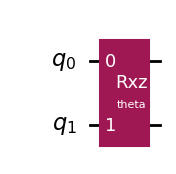

In [3]:
# Test the Gate


theta = Parameter("theta")
custom_gate = RXZGate(theta)

print("Gate name:", custom_gate.name)
print("Qubits:", custom_gate.num_qubits)
print("Parameters:", custom_gate.params)

qc = QuantumCircuit(2)
qc.append(custom_gate, [0, 1])
qc.draw("mpl")


In [4]:

# Inverse of RZX gate
bound_gate = RXZGate(0.1) # we can only compute the inverse of a gate if its parameters are bound to specific values

custom_gate_inv = bound_gate.inverse()

print(custom_gate_inv.to_matrix())

[[ 0.99875026+0.j          0.        +0.04997917j  0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.04997917j  0.99875026+0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.99875026+0.j
  -0.        -0.04997917j]
 [ 0.        +0.j          0.        +0.j         -0.        -0.04997917j
   0.99875026+0.j        ]]


Equivalence added to SessionEquivalenceLibrary.


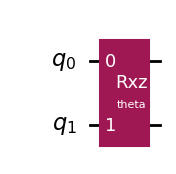

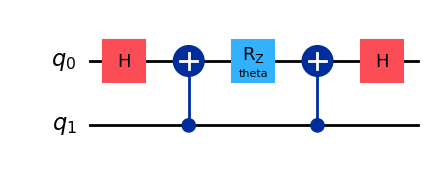

In [5]:
from qiskit.circuit import SessionEquivalenceLibrary
# SessionEquivalenceLibrary library provides a one-way mapping of Gates to their equivalent implementations as QuantumCircuits.

equiv = QuantumCircuit(2)
equiv.h(0)
equiv.cx(1, 0)
equiv.rz(theta, 0)
equiv.cx(1, 0)
equiv.h(0)
 
# SessionEquivalenceLibrary.add_equivalence(RXZGate(theta), equiv) # we are explicitly telling Qiskit that the custom RXZGate is equivalent to the sequence of gates in the equiv circuit, so that Qiskit can use this equivalence during transpilation and other processes.
print("Equivalence added to SessionEquivalenceLibrary.")

qc = QuantumCircuit(2)
qc.append(RXZGate(theta), [0, 1])
display(qc.draw('mpl')) # nothing happens

# Transpile the circuit to see the equivalence in action
from qiskit import transpile
qc_transpiled = transpile(qc, basis_gates=["h", "cx", "rz"])
display(qc_transpiled.draw('mpl')) # the RXZ gate is replaced by the equivalent sequence of gates we defined in the SessionEquivalenceLibrary. 




___
___